# Week 14

# Lecture 23: Gaussian Mixture and Hierarchical Clustering

We continue with the standardized Wine dataset so that model assumptions and cluster shapes—not changing data—explain differences between methods.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names = np.array(wine.feature_names)
X_scaled = StandardScaler().fit_transform(X_wine)

# Use the same two-dimensional PCA view in every clustering lecture.
pca = PCA(n_components=2)
X_view = pca.fit_transform(X_scaled)

def plot_clusters(labels, title, centers=None):
    plt.figure(figsize=(8, 6))
    for label in np.unique(labels):
        mask = labels == label
        name = 'Noise' if label == -1 else f'Cluster {label}'
        plt.scatter(X_view[mask, 0], X_view[mask, 1], s=35, alpha=0.75, label=name)
    if centers is not None:
        centers_view = pca.transform(centers)
        plt.scatter(centers_view[:, 0], centers_view[:, 1], marker='X', s=220,
                    c='black', edgecolor='white', label='Centers')
    plt.xlabel('Principal component 1')
    plt.ylabel('Principal component 2')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def report_clustering(labels, name):
    clustered = labels != -1
    n_clusters = len(set(labels[clustered]))
    print(f'{name}: {n_clusters} clusters; {(~clustered).sum()} noise points')
    print('Adjusted Rand index:', round(adjusted_rand_score(y_wine, labels), 3))
    if n_clusters > 1 and clustered.sum() > n_clusters:
        print('Silhouette score:', round(silhouette_score(X_scaled[clustered], labels[clustered]), 3))


## Gaussian mixture models

A Gaussian mixture returns soft membership probabilities. Ellipsoidal covariance estimates make it more flexible than spherical K-means clusters.


BIC-selected component count: 2
Three-component Gaussian mixture: 3 clusters; 0 noise points
Adjusted Rand index: 0.88
Silhouette score: 0.284
Five least-certain assignments: [0.639 0.963 0.97  0.97  0.987]


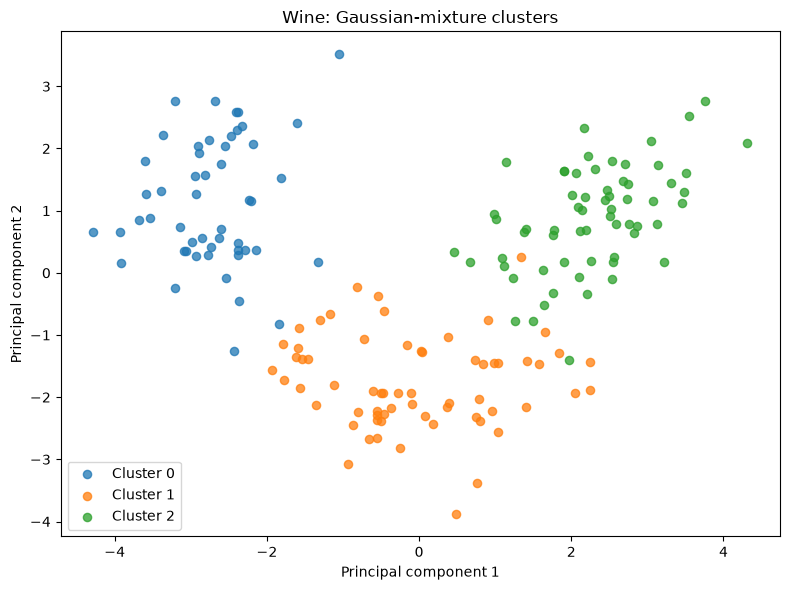

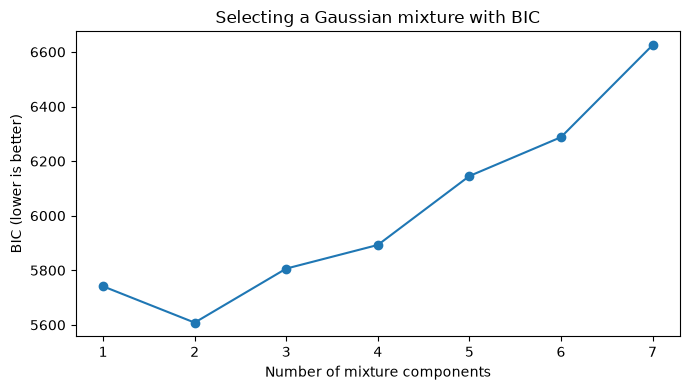

In [2]:
from sklearn.mixture import GaussianMixture

models = []
for k in range(1, 8):
    model = GaussianMixture(n_components=k, covariance_type='full', n_init=10, random_state=7)
    model.fit(X_scaled)
    models.append(model)

bic = np.array([model.bic(X_scaled) for model in models])
best = models[bic.argmin()]
# Use three components for comparison with the three Wine cultivars.
gmm = models[2]
gmm_labels = gmm.predict(X_scaled)
probabilities = gmm.predict_proba(X_scaled)

print('BIC-selected component count:', best.n_components)
report_clustering(gmm_labels, 'Three-component Gaussian mixture')
print('Five least-certain assignments:', np.round(np.sort(probabilities.max(axis=1))[:5], 3))
plot_clusters(gmm_labels, 'Wine: Gaussian-mixture clusters')

plt.figure(figsize=(7, 4))
plt.plot(range(1, 8), bic, marker='o')
plt.xlabel('Number of mixture components')
plt.ylabel('BIC (lower is better)')
plt.title('Selecting a Gaussian mixture with BIC')
plt.tight_layout()
plt.show()


## Hierarchical agglomerative clustering

Agglomerative clustering begins with one cluster per observation and repeatedly merges the closest clusters. A dendrogram records the entire merge hierarchy.


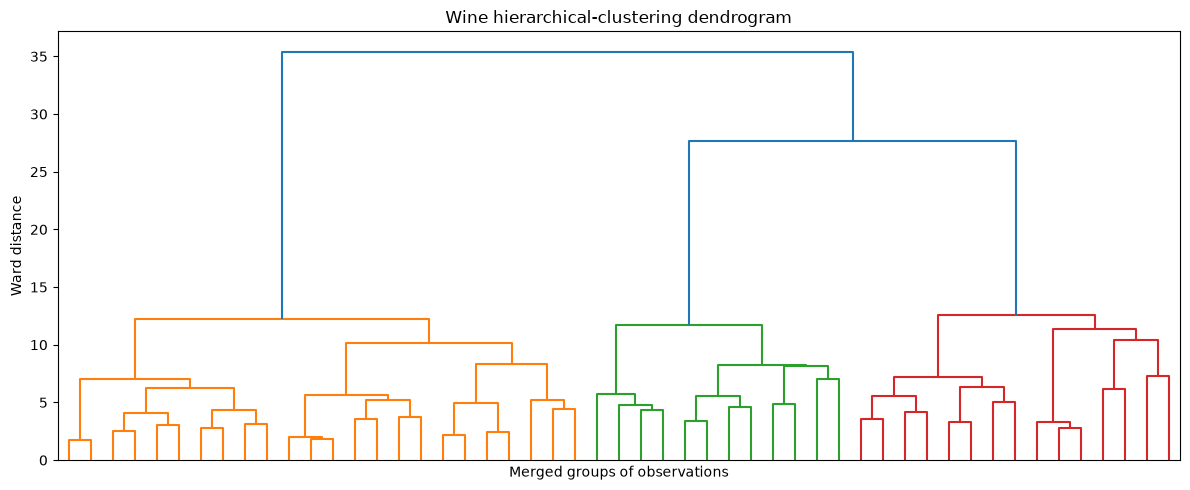

Ward hierarchical: 3 clusters; 0 noise points
Adjusted Rand index: 0.79
Silhouette score: 0.277


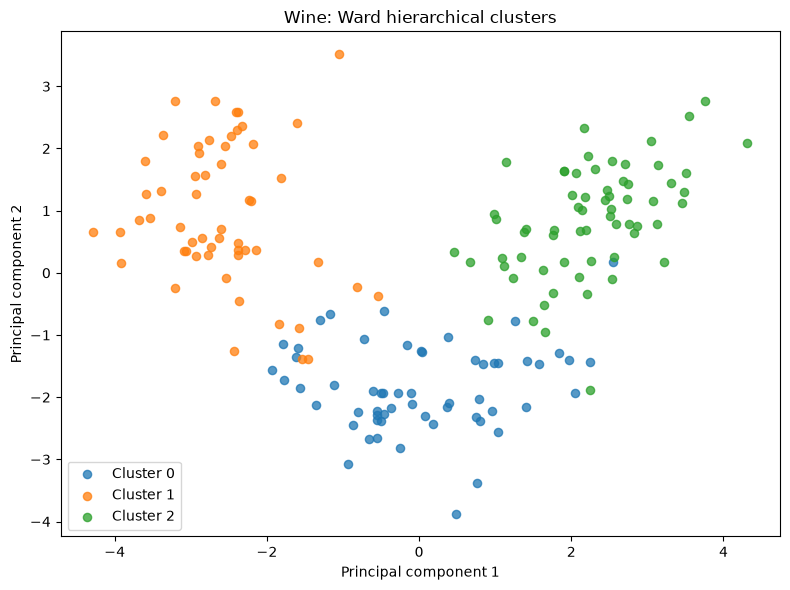

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode='level', p=5, no_labels=True)
plt.xlabel('Merged groups of observations')
plt.ylabel('Ward distance')
plt.title('Wine hierarchical-clustering dendrogram')
plt.tight_layout()
plt.show()

hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)
report_clustering(hierarchical_labels, 'Ward hierarchical')
plot_clusters(hierarchical_labels, 'Wine: Ward hierarchical clusters')


# Lecture 24: Density-Based Clustering—DBSCAN and OPTICS

Density-based methods can discover irregularly shaped clusters and identify noise. Their results depend strongly on distance scale, so standardized variables are essential here.


## Choosing a DBSCAN neighborhood radius

The sorted distance to each observation's nearest neighbors provides a diagnostic. An elbow suggests a candidate value for $\varepsilon$.


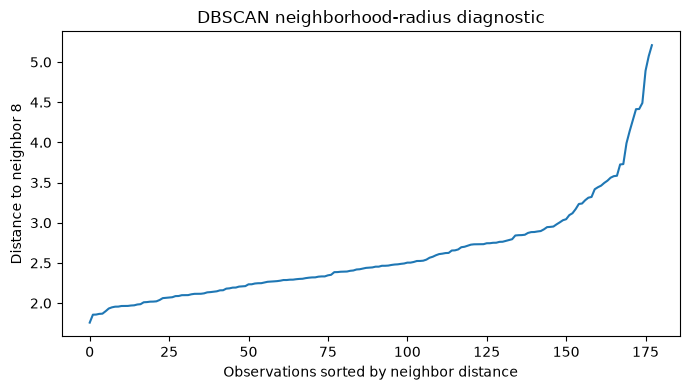

In [4]:
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.neighbors import NearestNeighbors

min_samples = 8
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_distances)
plt.xlabel('Observations sorted by neighbor distance')
plt.ylabel(f'Distance to neighbor {min_samples}')
plt.title('DBSCAN neighborhood-radius diagnostic')
plt.tight_layout()
plt.show()


DBSCAN: 2 clusters; 43 noise points
Adjusted Rand index: 0.373
Silhouette score: 0.335


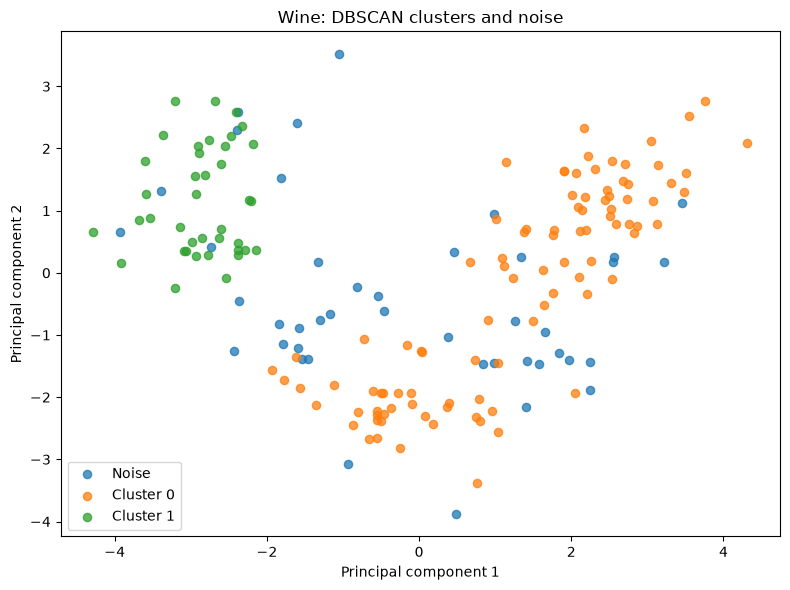

In [5]:
# Adjust eps after inspecting the k-distance curve.
dbscan = DBSCAN(eps=2.4, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)
report_clustering(dbscan_labels, 'DBSCAN')
plot_clusters(dbscan_labels, 'Wine: DBSCAN clusters and noise')


## OPTICS

OPTICS orders observations by density reachability and can extract clusters across varying density levels. The reachability plot exposes valleys corresponding to dense groups.


OPTICS: 2 clusters; 45 noise points
Adjusted Rand index: 0.372
Silhouette score: 0.336


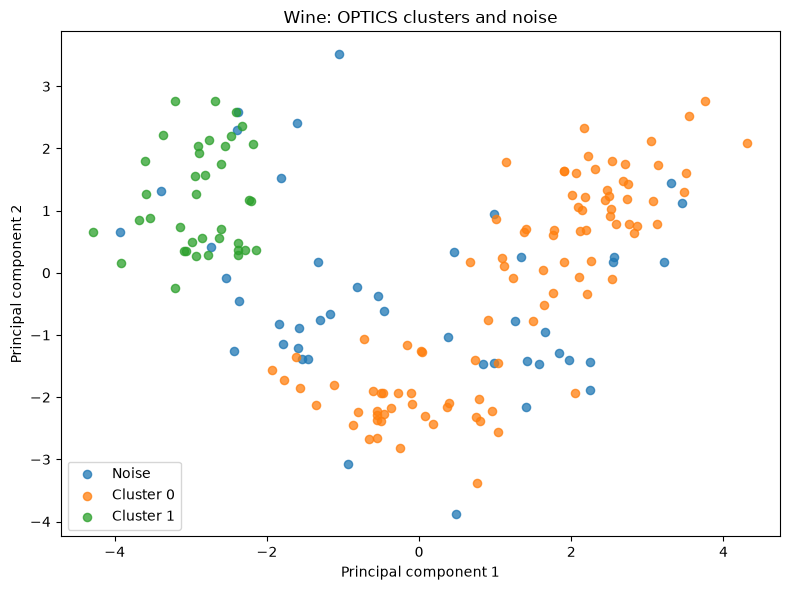

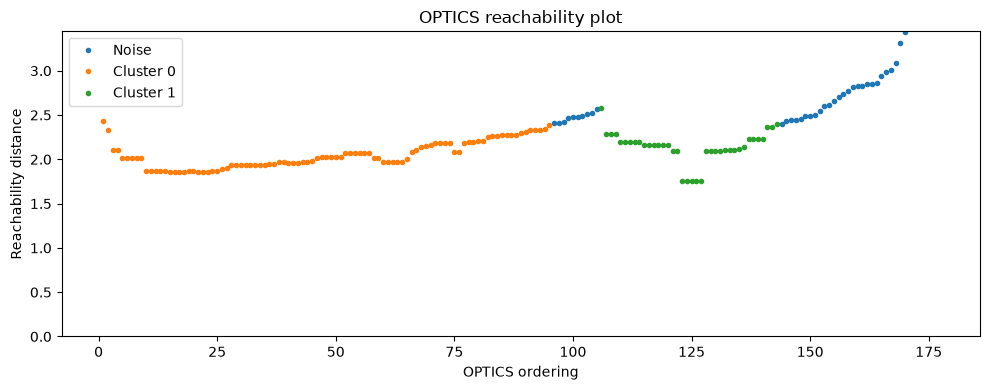

In [6]:
optics = OPTICS(min_samples=8, cluster_method='dbscan', eps=2.4)
optics_labels = optics.fit_predict(X_scaled)
report_clustering(optics_labels, 'OPTICS')
plot_clusters(optics_labels, 'Wine: OPTICS clusters and noise')

ordering = optics.ordering_
reachability = optics.reachability_[ordering]
ordered_labels = optics_labels[ordering]

plt.figure(figsize=(10, 4))
for label in np.unique(ordered_labels):
    mask = ordered_labels == label
    plt.plot(np.flatnonzero(mask), reachability[mask], '.', label='Noise' if label == -1 else f'Cluster {label}')
plt.ylim(0, np.nanpercentile(reachability[np.isfinite(reachability)], 95) * 1.1)
plt.xlabel('OPTICS ordering')
plt.ylabel('Reachability distance')
plt.title('OPTICS reachability plot')
plt.legend()
plt.tight_layout()
plt.show()
